In [1]:
%pip install -q earthengine-api geopandas rasterio shapely pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os, glob, time, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
warnings.filterwarnings('ignore')

# ===== KONFIGURASI =====
BASE   = '.'    # folder berisi 6 folder kelas (sejajar dengan notebook ini)
URUTAN = []     # opsional, contoh: ['sawah','bangunan','mangrove','lahan_hijau','perairan_laut','danau_ranu']
# =======================

print('Folder kerja:', os.path.abspath(BASE))

folders = sorted(
    d for d in os.listdir(BASE)
    if os.path.isdir(os.path.join(BASE, d))
    and not d.startswith(('.', '_'))
    and glob.glob(os.path.join(BASE, d, '**', '*.shp'), recursive=True)
)
if URUTAN:
    folders = [f for f in URUTAN if f in folders]

KELAS = {f: (i + 1, f) for i, f in enumerate(folders)}
print('Kelas terdeteksi:')
for f, (cid, cname) in KELAS.items():
    print(f'  {cid}: {cname}')
assert len(KELAS) == 6, f'Terdeteksi {len(KELAS)} kelas, seharusnya 6. Cek nama folder / isi URUTAN.'

parts = []
for folder, (cid, cname) in KELAS.items():
    for shp in glob.glob(os.path.join(BASE, folder, '**', '*.shp'), recursive=True):
        g = gpd.read_file(shp)
        if g.crs is None:
            print(f'[!] {shp} tidak punya CRS, diasumsikan EPSG:4326')
            g = g.set_crs(4326)
        g = g.to_crs(4326)[['geometry']].copy()
        g['class_id']    = cid
        g['class_name']  = cname
        g['class_label'] = cname.replace('_', ' ').title()
        g['folder']      = folder
        g['source_file'] = os.path.basename(shp)
        parts.append(g)

gdf = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), geometry='geometry', crs=4326)
print('\nTotal fitur mentah:', len(gdf))
print(gdf.groupby(['class_id', 'class_name']).size())

Folder kerja: c:\Users\ARIEL\OneDrive\Documents\PSD\materi
Kelas terdeteksi:
  1: bangunan
  2: danau
  3: lahanhijau
  4: laut
  5: mangrove
  6: sawah

Total fitur mentah: 285
class_id  class_name
1         bangunan      50
2         danau         50
3         lahanhijau    50
4         laut          35
5         mangrove      50
6         sawah         50
dtype: int64


In [2]:
from shapely.validation import make_valid

gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
gdf['geometry'] = gdf.geometry.apply(lambda x: make_valid(x) if not x.is_valid else x)

gdf = gdf.explode(index_parts=False).reset_index(drop=True)
gdf = gdf[gdf.geom_type == 'Polygon'].reset_index(drop=True)

gdf['poly_id'] = range(1, len(gdf) + 1)

utm = gdf.to_crs(32749)                      # UTM 49S, satuan meter
gdf['area_m2']       = utm.area.round(2)
gdf['area_ha']       = (utm.area / 10000).round(4)
gdf['perimeter_m']   = utm.length.round(2)
gdf['est_pixel_10m'] = (utm.area / 100).round(0).astype(int)

c = gdf.geometry.centroid
gdf['lon'] = c.x.round(6)
gdf['lat'] = c.y.round(6)

gdf = gdf[['poly_id','class_id','class_name','class_label','folder','source_file',
           'area_m2','area_ha','perimeter_m','est_pixel_10m','lon','lat','geometry']]
gdf.head()

,poly_id,class_id,class_name,class_label,folder,source_file,area_m2,area_ha,perimeter_m,est_pixel_10m,lon,lat,geometry
0,1,1,bangunan,Bangunan,bangunan,bangunan.shp,10540.05,1.0540,537.37,105,112.768033,-7.319891,"POLYGON ((112.76819 -7.32047, 112.76806 -7.320..."
1,2,1,bangunan,Bangunan,bangunan,bangunan.shp,1983.26,0.1983,201.34,20,112.712836,-7.482169,"POLYGON ((112.71254 -7.48223, 112.71264 -7.481..."
2,3,1,bangunan,Bangunan,bangunan,bangunan.shp,2475.74,0.2476,311.54,25,112.558990,-7.653677,"POLYGON ((112.5587 -7.65348, 112.55873 -7.6533..."
3,4,1,bangunan,Bangunan,bangunan,bangunan.shp,6671.11,0.6671,405.22,67,112.132128,-7.590508,"POLYGON ((112.13138 -7.59055, 112.1324 -7.5901..."
4,5,1,bangunan,Bangunan,bangunan,bangunan.shp,1046.73,0.1047,131.59,10,112.413256,-7.489239,"POLYGON ((112.41308 -7.48912, 112.41343 -7.489..."


In [3]:
# batas kasar Jawa Timur + perairan sekitarnya (sengaja longgar)
J = dict(minx=110.5, maxx=115.0, miny=-9.3, maxy=-6.3)
HAPUS_LUAR = True      # ubah ke False kalau poligon di luar batas itu memang benar

print('Batas data (minx, miny, maxx, maxy):', gdf.total_bounds.round(3))
luar = gdf[(gdf.lon < J['minx']) | (gdf.lon > J['maxx']) |
           (gdf.lat < J['miny']) | (gdf.lat > J['maxy'])]
print('Poligon di luar batas:', len(luar))
if len(luar):
    display(luar[['poly_id','class_name','source_file','lon','lat','area_ha']])

if HAPUS_LUAR and len(luar):
    gdf = gdf[~gdf.poly_id.isin(luar.poly_id)].reset_index(drop=True)
    print('Dibuang', len(luar), 'poligon ->', len(gdf), 'tersisa')

Batas data (minx, miny, maxx, maxy): [110.716  -9.574 117.276  -4.258]
Poligon di luar batas: 27


,poly_id,class_name,source_file,lon,lat,area_ha
94,95,danau,danau.shp,112.672328,-5.771998,31.4062
150,151,laut,laut.shp,114.617026,-4.612307,568349.4843
151,152,laut,laut.shp,114.032113,-4.788876,544175.6409
152,153,laut,laut.shp,115.213798,-4.793515,539109.4618
153,154,laut,laut.shp,112.882332,-5.350691,783350.3150
154,155,laut,laut.shp,113.785932,-5.366297,615168.6527
155,156,laut,laut.shp,112.079927,-5.422413,647958.0914
156,157,laut,laut.shp,114.587378,-5.422937,637756.5465
157,158,laut,laut.shp,115.256078,-5.424059,529935.8577
158,159,laut,laut.shp,113.427651,-5.908446,611383.8733


Dibuang 27 poligon -> 266 tersisa


In [4]:
ringkas = gdf.groupby(['class_id','class_name']).agg(
    n_poligon=('poly_id','count'),
    luas_total_ha=('area_ha','sum'),
    luas_min_m2=('area_m2','min'),
    piksel_perkiraan=('est_pixel_10m','sum')
).round(2)
display(ringkas)

kecil = gdf[gdf.est_pixel_10m < 3]
print('Poligon sangat kecil (<3 piksel 10 m):', len(kecil))
print(kecil.groupby('class_name').size())

gdf.to_file('label_6kelas.geojson', driver='GeoJSON')
gdf.drop(columns='geometry').to_csv('label_6kelas_atribut.csv', index=False)
print('Tersimpan: label_6kelas.geojson & label_6kelas_atribut.csv')

,,n_poligon,luas_total_ha,luas_min_m2,piksel_perkiraan
class_id,class_name,,,,
1,bangunan,50,2413.63,5.31,241365
2,danau,49,706.34,1448.33,70635
3,lahanhijau,50,18452.87,371.70,1845288
4,laut,17,7979474.45,157.38,797947446
5,mangrove,50,1207.91,381.32,120793
6,sawah,50,4198.58,7129.41,419857


Poligon sangat kecil (<3 piksel 10 m): 7
class_name
bangunan    6
laut        1
dtype: int64
Tersimpan: label_6kelas.geojson & label_6kelas_atribut.csv


In [5]:
import ee

PROJECT_ID = 'utspsd-511211'
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()          # buka browser, login, tempel kode kembali ke VS Code
    ee.Initialize(project=PROJECT_ID)
print('GEE OK:', ee.Number(1).getInfo())

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


GEE OK: 1


In [6]:
from shapely.geometry import Point
from shapely.prepared import prep
from pyproj import Transformer

# ===== KONFIGURASI EKSPERIMEN =====
N_PER_CLASS  = 1500    # target titik per kelas (coba 500 / 1500 / 3000)
MAX_PER_POLY = 150     # batas titik per poligon, agar tidak didominasi poligon besar
SEED         = 42
# ==================================

rng = np.random.default_rng(SEED)

def rand_pts(poly, n, max_try=200):
    minx, miny, maxx, maxy = poly.bounds
    pp = prep(poly)
    out, tries = [], 0
    while len(out) < n and tries < n * max_try:
        tries += 1
        p = Point(rng.uniform(minx, maxx), rng.uniform(miny, maxy))
        if pp.contains(p):
            out.append(p)
    return out

rows = []
for cid, grp in gdf.groupby('class_id'):
    w = grp.area_m2 / grp.area_m2.sum()                 # jatah titik sebanding luas poligon
    for (_, r), wi in zip(grp.iterrows(), w):
        n = int(np.clip(round(N_PER_CLASS * wi), 1, MAX_PER_POLY))
        n = min(n, max(1, int(r.est_pixel_10m)))        # jangan melebihi jumlah piksel poligon
        for p in rand_pts(r.geometry, n):
            rows.append({'poly_id': r.poly_id, 'class_id': r.class_id,
                         'class_name': r.class_name, 'class_label': r.class_label,
                         'lon': p.x, 'lat': p.y})

pts = pd.DataFrame(rows)

# buang titik yang jatuh di piksel 10 m yang sama
tr = Transformer.from_crs(4326, 32749, always_xy=True)
x, y = tr.transform(pts.lon.values, pts.lat.values)
pts['gx'] = np.floor(x / 10).astype(int)
pts['gy'] = np.floor(y / 10).astype(int)
pts = (pts.drop_duplicates(['gx', 'gy']).drop(columns=['gx', 'gy'])
          .sort_values(['class_id', 'poly_id']).reset_index(drop=True))

print('Total titik:', len(pts))
print(pts.groupby('class_name').agg(titik=('poly_id', 'size'), poligon=('poly_id', 'nunique')))

Total titik: 6934
            titik  poligon
class_name                
bangunan      647       50
danau        1022       49
lahanhijau   1330       50
laut         1503       17
mangrove      989       50
sawah        1443       50


In [7]:
# ===== KONFIGURASI CITRA =====
TGL_MULAI, TGL_AKHIR = '2025-05-01', '2025-10-31'
MAX_CLOUD = 30
BANDS = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
BATCH = 300            # kecilkan ke 100-150 kalau muncul error timeout / memory
# =============================

def mask_s2(img):
    scl = img.select('SCL')
    m = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))   # bayangan, awan, cirrus
    return img.updateMask(m)

def build_s2(region):
    return (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(region)
            .filterDate(TGL_MULAI, TGL_AKHIR)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', MAX_CLOUD))
            .map(mask_s2).select(BANDS).median())

PROJ = ee.Projection('EPSG:32749')

def sample_batch(df_b):
    feats = [ee.Feature(ee.Geometry.Point([r['lon'], r['lat']]),
                        {'poly_id': int(r['poly_id']), 'class_id': int(r['class_id']),
                         'class_name': r['class_name'], 'class_label': r['class_label'],
                         'lon': float(r['lon']), 'lat': float(r['lat'])})
             for r in df_b.to_dict('records')]
    fc = ee.FeatureCollection(feats)
    img = build_s2(fc.geometry().bounds())
    out = img.sampleRegions(collection=fc, scale=10, projection=PROJ, tileScale=4)
    res = out.getInfo()['features']
    return pd.DataFrame([f['properties'] for f in res])

def sample_retry(df_b, tries=3):
    for k in range(tries):
        try:
            return sample_batch(df_b)
        except Exception as e:
            print('   ulang', k + 1, '->', str(e)[:150])
            time.sleep(5 * (k + 1))
    return pd.DataFrame()

hasil = []
n_batch = int(np.ceil(len(pts) / BATCH))
for i in range(n_batch):
    d = sample_retry(pts.iloc[i * BATCH:(i + 1) * BATCH])
    hasil.append(d)
    print(f'Batch {i+1}/{n_batch}: {len(d)}/{min(BATCH, len(pts) - i*BATCH)} titik berhasil')

df_pix = pd.concat(hasil, ignore_index=True)
df_pix = df_pix.dropna(subset=BANDS).reset_index(drop=True)
print('\nTitik dikirim:', len(pts), '| titik dengan nilai valid:', len(df_pix))
print(df_pix['class_name'].value_counts())

Batch 1/24: 300/300 titik berhasil
Batch 2/24: 300/300 titik berhasil
Batch 3/24: 300/300 titik berhasil
Batch 4/24: 300/300 titik berhasil
Batch 5/24: 300/300 titik berhasil
Batch 6/24: 300/300 titik berhasil
Batch 7/24: 300/300 titik berhasil
Batch 8/24: 300/300 titik berhasil
Batch 9/24: 300/300 titik berhasil
Batch 10/24: 300/300 titik berhasil
Batch 11/24: 300/300 titik berhasil
Batch 12/24: 300/300 titik berhasil
Batch 13/24: 290/300 titik berhasil
Batch 14/24: 268/300 titik berhasil
Batch 15/24: 294/300 titik berhasil
Batch 16/24: 300/300 titik berhasil
Batch 17/24: 300/300 titik berhasil
Batch 18/24: 300/300 titik berhasil
Batch 19/24: 300/300 titik berhasil
Batch 20/24: 300/300 titik berhasil
Batch 21/24: 300/300 titik berhasil
Batch 22/24: 300/300 titik berhasil
Batch 23/24: 300/300 titik berhasil
Batch 24/24: 34/34 titik berhasil

Titik dikirim: 6934 | titik dengan nilai valid: 6886
class_name
laut          1455
sawah         1443
lahanhijau    1330
danau         1022
mangro

In [8]:
EPS = 1e-9

def hitung_indeks(B):
    # B: dict nama_band -> reflektansi (skala 0-1)
    return {
        'NDVI':  (B['B8']  - B['B4'])  / (B['B8']  + B['B4']  + EPS),
        'NDWI':  (B['B3']  - B['B8'])  / (B['B3']  + B['B8']  + EPS),
        'MNDWI': (B['B3']  - B['B11']) / (B['B3']  + B['B11'] + EPS),
        'NDBI':  (B['B11'] - B['B8'])  / (B['B11'] + B['B8']  + EPS),
        'NDMI':  (B['B8']  - B['B11']) / (B['B8']  + B['B11'] + EPS),
        'NBR':   (B['B8']  - B['B12']) / (B['B8']  + B['B12'] + EPS),
        'NDRE':  (B['B8A'] - B['B5'])  / (B['B8A'] + B['B5']  + EPS),
        'SAVI':  1.5 * (B['B8'] - B['B4']) / (B['B8'] + B['B4'] + 0.5),
        'EVI':   2.5 * (B['B8'] - B['B4']) / (B['B8'] + 6*B['B4'] - 7.5*B['B2'] + 1),
    }

B = {b: df_pix[b] / 10000 for b in BANDS}     # reflektansi = nilai / 10000
idx = hitung_indeks(B)
for nama, nilai in idx.items():
    df_pix[nama] = nilai

kolom = ['poly_id','class_id','class_name','class_label','lon','lat'] + BANDS + list(idx.keys())
df_pix = df_pix[kolom]

print(df_pix.shape)
display(df_pix.groupby('class_name')[['NDVI','NDWI','MNDWI','NDBI']].mean().round(3))
df_pix.head()

(6886, 25)


,NDVI,NDWI,MNDWI,NDBI
class_name,,,,
bangunan,0.259,-0.280,-0.330,0.045
danau,-0.286,0.472,0.396,0.113
lahanhijau,0.714,-0.642,-0.543,-0.159
laut,-0.106,0.253,0.250,-0.007
mangrove,0.747,-0.609,-0.243,-0.439
sawah,0.452,-0.357,-0.178,-0.215


,poly_id,class_id,class_name,class_label,lon,lat,B2,B3,B4,B5,...,B12,NDVI,NDWI,MNDWI,NDBI,NDMI,NBR,NDRE,SAVI,EVI
0,1,1,bangunan,Bangunan,112.768325,-7.319541,617.5,1060.0,2087.0,2076.0,...,2599.0,0.071619,-0.388873,-0.456062,0.081673,-0.081673,-0.037939,0.017743,0.050864,0.039656
1,2,1,bangunan,Bangunan,112.712617,-7.482169,1381.0,1623.0,1560.0,2246.0,...,2078.0,0.299820,-0.281699,-0.241766,-0.042852,0.042852,0.164455,0.150369,0.211929,0.280708
2,3,1,bangunan,Bangunan,112.558928,-7.653332,820.0,974.0,1200.0,1227.0,...,1884.0,0.138550,-0.239062,-0.372423,0.146394,-0.146394,-0.085879,0.149098,0.074364,0.076369
3,4,1,bangunan,Bangunan,112.132210,-7.590182,994.0,1087.0,1148.0,1216.5,...,1264.0,0.106267,-0.133174,-0.178227,0.046149,-0.046149,0.058473,0.177207,0.054102,0.062880
4,5,1,bangunan,Bangunan,112.413238,-7.489306,586.0,843.5,926.0,1477.0,...,1701.0,0.483979,-0.518893,-0.494001,-0.033472,0.033472,0.220440,0.389291,0.303353,0.314128


In [9]:
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
SPLIT_SEED = 42
rng2 = np.random.default_rng(SPLIT_SEED)

split_map = {}
for cid, g in df_pix.groupby('class_id'):
    ids = g.poly_id.unique().copy()
    rng2.shuffle(ids)
    n = len(ids)
    if n < 3:
        print(f'[!] Kelas {g.class_name.iloc[0]} hanya {n} poligon, tidak bisa dipecah 3 bagian (semua masuk train)')
        n_val = n_test = 0
    else:
        n_val  = max(1, int(round(n * VAL_FRAC)))
        n_test = max(1, int(round(n * TEST_FRAC)))
    for pid in ids[:n_test]:               split_map[pid] = 'test'
    for pid in ids[n_test:n_test + n_val]: split_map[pid] = 'val'
    for pid in ids[n_test + n_val:]:       split_map[pid] = 'train'

df_pix['split'] = df_pix.poly_id.map(split_map)

print('Jumlah kelas:', df_pix.class_id.nunique())
print('\nJumlah data (piksel) per kelas dan split:')
display(pd.crosstab(df_pix.class_name, df_pix.split, margins=True)[['train','val','test','All']])
print('Proporsi piksel aktual (%):')
print((df_pix.split.value_counts(normalize=True) * 100).round(1))
print('\nJumlah poligon per kelas dan split:')
display(df_pix.groupby(['class_name', 'split']).poly_id.nunique().unstack(fill_value=0)[['train','val','test']])

df_pix.to_csv('dataset_pixel.csv', index=False)
for s in ['train', 'val', 'test']:
    df_pix[df_pix.split == s].to_csv(f'dataset_{s}.csv', index=False)
print('Tersimpan: dataset_pixel.csv, dataset_train.csv, dataset_val.csv, dataset_test.csv')

Jumlah kelas: 6

Jumlah data (piksel) per kelas dan split:


split,train,val,test,All
class_name,,,,
bangunan,530,97,20,647
danau,597,266,159,1022
lahanhijau,1179,50,101,1330
laut,969,205,281,1455
mangrove,508,463,18,989
sawah,1034,198,211,1443
All,4817,1279,790,6886


Proporsi piksel aktual (%):
split
train    70.0
val      18.6
test     11.5
Name: proportion, dtype: float64

Jumlah poligon per kelas dan split:


split,train,val,test
class_name,,,
bangunan,34,8,8
danau,35,7,7
lahanhijau,34,8,8
laut,11,3,3
mangrove,34,8,8
sawah,34,8,8


Tersimpan: dataset_pixel.csv, dataset_train.csv, dataset_val.csv, dataset_test.csv


In [10]:
%pip install -q scikit-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


In [11]:
import joblib
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             confusion_matrix, classification_report)

IDX = ['NDVI','NDWI','MNDWI','NDBI','NDMI','NBR','NDRE','SAVI','EVI']
FITUR = {
    'Band saja':     BANDS,
    'Indeks saja':   IDX,
    'Band + indeks': BANDS + IDX,
}

tr = df_pix[df_pix.split == 'train']
va = df_pix[df_pix.split == 'val']
te = df_pix[df_pix.split == 'test']
ytr, yva, yte = tr.class_id, va.class_id, te.class_id

nama_kelas = df_pix.drop_duplicates('class_id').sort_values('class_id').set_index('class_id').class_label
labels = list(nama_kelas.index)

def metrik(y, p):
    return {'Akurasi': accuracy_score(y, p),
            'F1_macro': f1_score(y, p, average='macro'),
            'Kappa': cohen_kappa_score(y, p)}

rows = []
for fn, cols in FITUR.items():
    model_awal = {
        'Naive Bayes': GaussianNB(),
        'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    }
    for mn, mdl in model_awal.items():
        mdl.fit(tr[cols], ytr)
        rows.append({'Model': mn, 'Fitur': fn, **metrik(yva, mdl.predict(va[cols]))})

hasil_val = pd.DataFrame(rows).sort_values('F1_macro', ascending=False).reset_index(drop=True)
display(hasil_val.round(4))

,Model,Fitur,Akurasi,F1_macro,Kappa
0,KNN,Band + indeks,0.8022,0.7342,0.7470
1,KNN,Band saja,0.7803,0.7168,0.7189
2,KNN,Indeks saja,0.7654,0.7070,0.6994
3,Naive Bayes,Band + indeks,0.7271,0.6495,0.6518
4,Naive Bayes,Indeks saja,0.7131,0.6303,0.6340
5,Naive Bayes,Band saja,0.6763,0.5981,0.5874


Fitur terbaik KNN: Band + indeks | Naive Bayes: Band + indeks


,k,weights,Akurasi,F1_macro,Kappa
0,7,distance,0.8045,0.7446,0.7498
1,9,distance,0.8030,0.7445,0.7479
2,11,distance,0.8038,0.7429,0.7489
3,7,uniform,0.8014,0.7392,0.7461
4,11,uniform,0.7991,0.7384,0.7433
5,9,uniform,0.7983,0.7379,0.7421
6,5,uniform,0.8022,0.7342,0.7470
7,5,distance,0.7975,0.7319,0.7407
8,15,distance,0.7889,0.7305,0.7305
9,15,uniform,0.7873,0.7285,0.7285


KNN terbaik: k = 7 | weights = distance


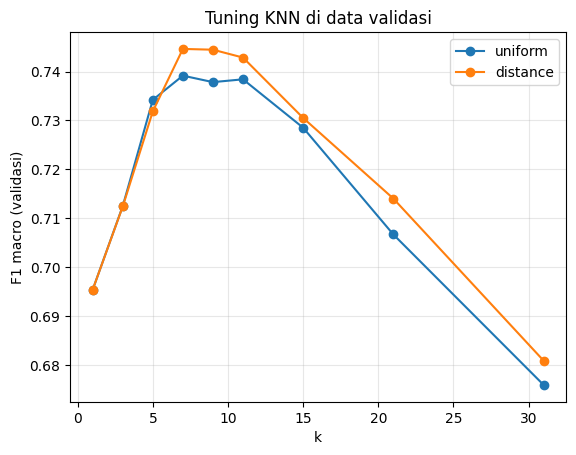

In [12]:
fs_knn = hasil_val[hasil_val.Model == 'KNN'].iloc[0].Fitur
fs_nb  = hasil_val[hasil_val.Model == 'Naive Bayes'].iloc[0].Fitur
print('Fitur terbaik KNN:', fs_knn, '| Naive Bayes:', fs_nb)

cols = FITUR[fs_knn]
rows = []
for k in [1, 3, 5, 7, 9, 11, 15, 21, 31]:
    for w in ['uniform', 'distance']:
        m = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k, weights=w))
        m.fit(tr[cols], ytr)
        rows.append({'k': k, 'weights': w, **metrik(yva, m.predict(va[cols]))})

tuning = pd.DataFrame(rows).sort_values('F1_macro', ascending=False).reset_index(drop=True)
display(tuning.head(10).round(4))
best_k, best_w = int(tuning.loc[0, 'k']), tuning.loc[0, 'weights']
print('KNN terbaik: k =', best_k, '| weights =', best_w)

# kurva k vs F1
for w in ['uniform', 'distance']:
    d = tuning[tuning.weights == w].sort_values('k')
    plt.plot(d.k, d.F1_macro, marker='o', label=w)
plt.xlabel('k'); plt.ylabel('F1 macro (validasi)'); plt.legend(); plt.grid(alpha=.3)
plt.title('Tuning KNN di data validasi'); plt.show()

,Model,Fitur,Akurasi,F1_macro,Kappa
0,Naive Bayes,B2 ...,0.5772,0.4721,0.4705
1,"KNN (k=7, distance)",B2 ...,0.9000,0.8163,0.8671



===== Naive Bayes =====
              precision    recall  f1-score   support

    Bangunan      0.117     0.800     0.204        20
       Danau      0.470     0.195     0.276       159
  Lahanhijau      0.458     0.960     0.620       101
        Laut      0.895     0.879     0.887       281
    Mangrove      0.342     0.722     0.464        18
       Sawah      0.852     0.246     0.382       211

    accuracy                          0.577       790
   macro avg      0.522     0.634     0.472       790
weighted avg      0.710     0.577     0.568       790


===== KNN (k=7, distance) =====
              precision    recall  f1-score   support

    Bangunan      0.571     0.800     0.667        20
       Danau      0.941     0.906     0.923       159
  Lahanhijau      0.780     0.950     0.857       101
        Laut      0.996     0.968     0.982       281
    Mangrove      0.542     0.722     0.619        18
       Sawah      0.899     0.806     0.850       211

    accuracy       

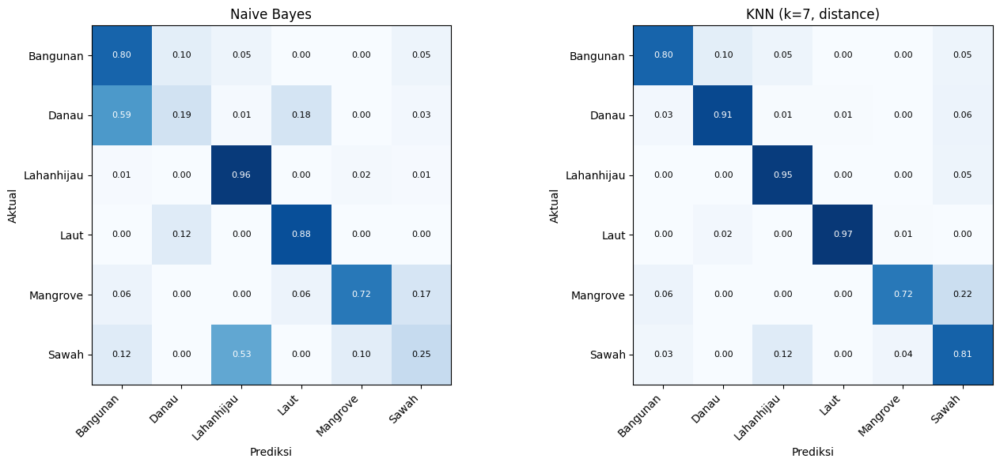

In [13]:
trva = pd.concat([tr, va])
ytrva = trva.class_id

final = {
    'Naive Bayes': (GaussianNB(), FITUR[fs_nb]),
    f'KNN (k={best_k}, {best_w})': (
        make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k, weights=best_w)),
        FITUR[fs_knn]),
}

hasil_test, pred = [], {}
for mn, (mdl, cols) in final.items():
    mdl.fit(trva[cols], ytrva)
    p = mdl.predict(te[cols])
    pred[mn] = p
    hasil_test.append({'Model': mn, 'Fitur': ' + '.join(cols[:1]) + ' ...' if len(cols) > 2 else cols, **metrik(yte, p)})

display(pd.DataFrame(hasil_test).round(4))

for mn, p in pred.items():
    print(f'\n===== {mn} =====')
    print(classification_report(yte, p, labels=labels,
                                target_names=[nama_kelas[l] for l in labels], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (mn, p) in zip(axes, pred.items()):
    cm = confusion_matrix(yte, p, labels=labels, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels([nama_kelas[l] for l in labels], rotation=45, ha='right')
    ax.set_yticklabels([nama_kelas[l] for l in labels])
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f'{cm[i, j]:.2f}', ha='center', va='center',
                    color='white' if cm[i, j] > .5 else 'black', fontsize=8)
    ax.set_title(mn); ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
plt.tight_layout(); plt.show()

In [14]:
for mn, (mdl, cols) in final.items():
    nama_file = 'model_' + mn.split(' (')[0].replace(' ', '_').lower() + '.joblib'
    joblib.dump({'model': mdl, 'fitur': cols, 'kelas': dict(nama_kelas)}, nama_file)
    print('Tersimpan:', nama_file)

hasil_val.to_csv('hasil_validasi.csv', index=False)
pd.DataFrame(hasil_test).to_csv('hasil_test.csv', index=False)

Tersimpan: model_naive_bayes.joblib
Tersimpan: model_knn.joblib


In [15]:
%pip install -q folium

Note: you may need to restart the kernel to use updated packages.


In [16]:
import io, zipfile, urllib.request
import rasterio
from rasterio.transform import from_origin
from pyproj import Transformer

# ===== KONFIGURASI PETA =====
AOI = dict(west=111.0, south=-8.9, east=114.6, north=-6.7)   # kotak area studi Jawa Timur
RES_M   = 200      # resolusi peta (meter). 200 = cepat | 100 = lebih detail tapi ~4x lebih lama
TILE_PX = 400      # ukuran tile unduhan (piksel); kecilkan kalau muncul error "request size"
# ============================

t_fw = Transformer.from_crs(4326, 3857, always_xy=True)
t_bw = Transformer.from_crs(3857, 4326, always_xy=True)
xmin, ymin = t_fw.transform(AOI['west'], AOI['south'])
xmax, ymax = t_fw.transform(AOI['east'], AOI['north'])

X0 = np.floor(xmin / RES_M) * RES_M
Y1 = np.ceil(ymax / RES_M) * RES_M
W = int(np.ceil((xmax - X0) / RES_M))
H = int(np.ceil((Y1 - ymin) / RES_M))
print(f'Grid peta: {W} x {H} piksel = {W*H/1e6:.2f} juta piksel | memori data ~ {W*H*len(BANDS)*4/1e6:.0f} MB')

mosaic = np.full((len(BANDS), H, W), np.nan, dtype='float32')

region_aoi = ee.Geometry.Rectangle([AOI['west'], AOI['south'], AOI['east'], AOI['north']])
img_map = build_s2(region_aoi).unmask(-9999).toFloat()

def unduh_tile(c0, r0, c1, r1, tries=3):
    x0, x1 = X0 + c0 * RES_M, X0 + c1 * RES_M
    ya, yb = Y1 - r1 * RES_M, Y1 - r0 * RES_M
    rect = ee.Geometry.Rectangle([x0, ya, x1, yb], proj='EPSG:3857', geodesic=False)
    for k in range(tries):
        try:
            url = img_map.getDownloadURL({'region': rect, 'scale': RES_M,
                                          'crs': 'EPSG:3857', 'format': 'GEO_TIFF'})
            return urllib.request.urlopen(url, timeout=300).read()
        except Exception as e:
            print('   ulang', k + 1, '->', str(e)[:150])
            time.sleep(5 * (k + 1))
    return None

def baca_tif(data):
    if data[:2] == b'PK':                      # zip: satu tif per band
        z = zipfile.ZipFile(io.BytesIO(data))
        arrs, tr = [], None
        for b in BANDS:
            nm = [n for n in z.namelist() if n.split('.')[-2] == b][0]
            with rasterio.MemoryFile(z.read(nm)) as mf, mf.open() as ds:
                arrs.append(ds.read(1)); tr = ds.transform
        return np.stack(arrs), tr
    with rasterio.MemoryFile(data) as mf, mf.open() as ds:
        return ds.read(), ds.transform

def tempel(arr, tr):
    c = int(round((tr.c - X0) / RES_M))
    r = int(round((Y1 - tr.f) / RES_M))
    _, h, w = arr.shape
    c0, r0 = max(c, 0), max(r, 0)
    c1, r1 = min(c + w, W), min(r + h, H)
    if c1 > c0 and r1 > r0:
        mosaic[:, r0:r1, c0:c1] = arr[:, r0 - r:r1 - r, c0 - c:c1 - c]

grid = [(c, r) for r in range(0, H, TILE_PX) for c in range(0, W, TILE_PX)]
gagal = []
for i, (c, r) in enumerate(grid, 1):
    data = unduh_tile(c, r, min(c + TILE_PX, W), min(r + TILE_PX, H))
    if data is None:
        gagal.append((c, r)); continue
    arr, tr = baca_tif(data)
    tempel(arr, tr)
    print(f'Tile {i}/{len(grid)} selesai', end='\r')

valid = np.isfinite(mosaic).all(axis=0) & (mosaic > -9000).all(axis=0) & (mosaic != 0).any(axis=0)
print(f'\nTile gagal: {len(gagal)} | piksel valid: {valid.sum():,} dari {H*W:,} ({valid.mean()*100:.1f}%)')

Grid peta: 2005 x 1237 piksel = 2.48 juta piksel | memori data ~ 99 MB
Tile 24/24 selesai
Tile gagal: 0 | piksel valid: 2,479,718 dari 2,480,185 (100.0%)


In [17]:
PAKAI_MODEL = None     # None = otomatis model dengan F1 test tertinggi, atau isi nama persis dari 'final'

best_row  = max(hasil_test, key=lambda d: d['F1_macro'])
best_name = PAKAI_MODEL or best_row['Model']
mdl, cols = final[best_name]
print('Model dipakai:', best_name, '| jumlah fitur:', len(cols))

try:                                           # percepat KNN
    mdl.set_params(kneighborsclassifier__n_jobs=-1)
except Exception:
    pass

def fitur_matrix(raw, cols):
    # raw: (n_piksel, n_band) nilai mentah
    Bd = {b: raw[:, i] / 10000 for i, b in enumerate(BANDS)}
    feats = {b: raw[:, i] for i, b in enumerate(BANDS)}
    feats.update(hitung_indeks(Bd))
    return pd.DataFrame({c: feats[c] for c in cols})

flat = mosaic.reshape(len(BANDS), -1).T
vi = np.flatnonzero(valid.ravel())
pred_flat = np.zeros(H * W, dtype='uint8')      # 0 = tidak ada data

CH = 200_000
t0 = time.time()
for s in range(0, len(vi), CH):
    sel = vi[s:s + CH]
    pred_flat[sel] = mdl.predict(fitur_matrix(flat[sel].astype('float64'), cols))
    print(f'Prediksi {min(s + CH, len(vi)):,}/{len(vi):,} piksel | {time.time()-t0:.0f} detik', end='\r')

klas = pred_flat.reshape(H, W)
print('\nSelesai.')
print(pd.Series(klas[klas > 0]).value_counts().sort_index())

Model dipakai: KNN (k=7, distance) | jumlah fitur: 19
Prediksi 2,479,718/2,479,718 piksel | 79 detik
Selesai.
1      86646
2      22988
3     794076
4    1081170
5       9008
6     485830
Name: count, dtype: int64


Peta disimpan: hasil_klasifikasi_knn.html (9.4 MB) - bisa ditanam di web statis lewat <iframe>



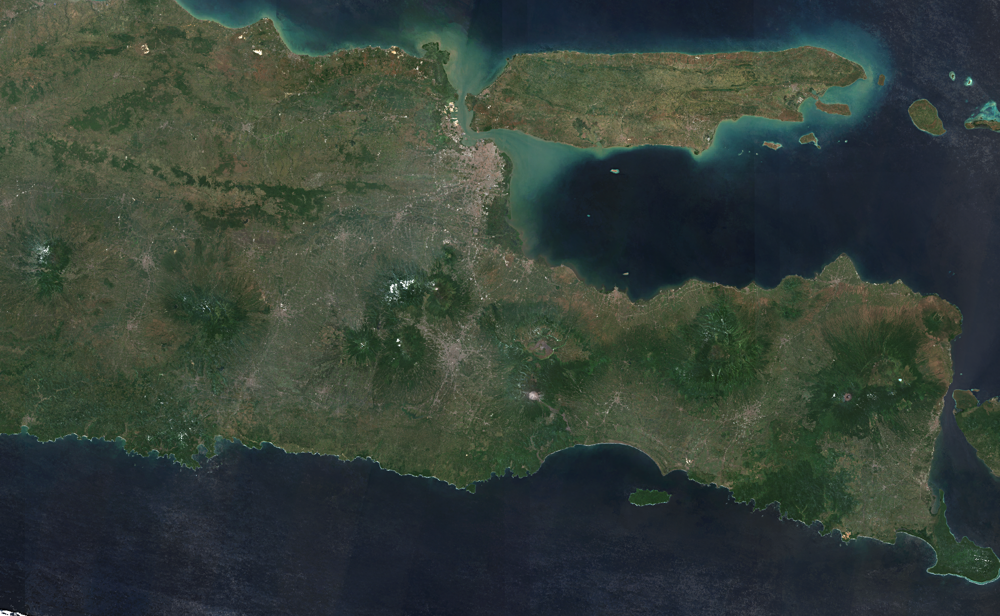
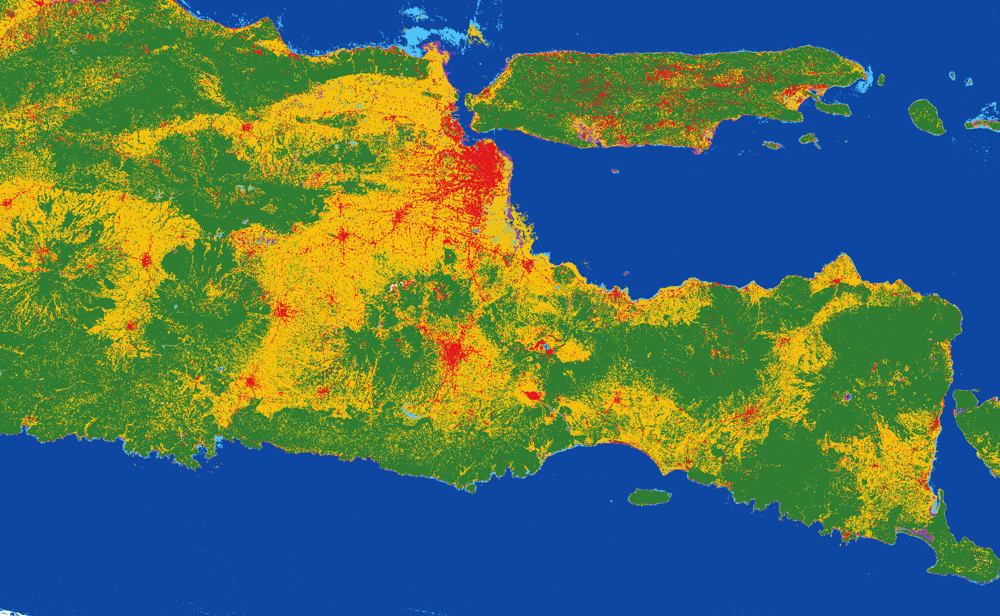

In [18]:
import folium
from folium.raster_layers import ImageOverlay

def warna(nama):
    n = nama.lower()
    if 'sawah' in n:                      return '#f4c20d'
    if 'bangun' in n:                     return '#e31a1c'
    if 'mangrove' in n:                   return '#8e44ad'
    if 'hijau' in n:                      return '#2e7d32'
    if 'danau' in n or 'ranu' in n:       return '#4fc3f7'
    if 'laut' in n or 'perairan' in n:    return '#0d47a1'
    return '#888888'

ref = df_pix.drop_duplicates('class_id').set_index('class_id').sort_index()
short = best_name.split(' (')[0]

# --- gambar klasifikasi (RGBA) ---
rgba = np.zeros((H, W, 4), dtype=np.uint8)
for cid, r in ref.iterrows():
    hx = warna(r.class_name)
    rgba[klas == cid] = [int(hx[1:3], 16), int(hx[3:5], 16), int(hx[5:7], 16), 255]

# --- gambar satelit tertanam (RGB dari B4,B3,B2) ---
sat = np.zeros((H, W, 4), dtype=np.uint8)
for k, b in enumerate(['B4', 'B3', 'B2']):
    band = np.where(valid, mosaic[BANDS.index(b)], 0)
    sat[..., k] = np.clip((band / 3000) ** 0.8 * 255, 0, 255).astype(np.uint8)
sat[..., 3] = np.where(valid, 255, 0)

# --- batas gambar dalam lat/lon ---
west, north = t_bw.transform(X0, Y1)
east, south = t_bw.transform(X0 + W * RES_M, Y1 - H * RES_M)
bounds = [[south, west], [north, east]]

# --- peta dasar ---
m = folium.Map(location=[-7.8, 112.8], zoom_start=8, tiles=None, control_scale=True)
m.get_root().header.add_child(folium.Element('<style>.lulc-pix{image-rendering:pixelated}</style>'))

folium.TileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
                 attr='Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics',
                 name='Esri Satellite (online)', overlay=False, show=True, max_zoom=19).add_to(m)
folium.TileLayer('https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}',
                 attr='Google', name='Google Hybrid (dengan label)',
                 overlay=False, show=False, max_zoom=20).add_to(m)
folium.TileLayer('https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
                 attr='Google', name='Google Satellite (tanpa label)',
                 overlay=False, show=False, max_zoom=20).add_to(m)

# --- overlay satelit tertanam & hasil klasifikasi ---
ImageOverlay(image=sat, bounds=bounds, opacity=1.0, name='Satelit (tertanam)',
             show=False, interactive=False, class_name='lulc-pix').add_to(m)
ImageOverlay(image=rgba, bounds=bounds, opacity=0.8, name=f'Hasil Klasifikasi {short}',
             show=True, interactive=False, class_name='lulc-pix').add_to(m)

# --- sampel training per kelas ---
for cid, r in ref.iterrows():
    fg = folium.FeatureGroup(name=f'Sampel: {r.class_label}', show=False)
    d = df_pix[df_pix.class_id == cid]
    d = d.sample(min(300, len(d)), random_state=1)
    for _, p in d.iterrows():
        folium.CircleMarker([p.lat, p.lon], radius=3, color='white', weight=1,
                            fill=True, fill_color=warna(r.class_name), fill_opacity=0.95,
                            tooltip=f'{r.class_label} | poligon {int(p.poly_id)} | {p.split}').add_to(fg)
    fg.add_to(m)

# --- batas area studi ---
folium.Rectangle([[AOI['south'], AOI['west']], [AOI['north'], AOI['east']]],
                 color='white', weight=2, dash_array='8 6', fill=False,
                 name='Batas area studi').add_to(m)

# --- legenda & info model ---
item = ''.join(
    f'<div style="margin:3px 0"><span style="display:inline-block;width:16px;height:16px;'
    f'background:{warna(r.class_name)};border:1px solid #666;vertical-align:middle;margin-right:8px"></span>'
    f'{r.class_label}</div>' for _, r in ref.iterrows())
legend = ('<div style="position:fixed;bottom:40px;left:20px;z-index:9999;background:white;'
          'padding:10px 14px;border-radius:8px;box-shadow:0 1px 6px rgba(0,0,0,.4);'
          'font-family:Arial;font-size:13px"><b>Legenda LULC</b>' + item + '</div>')
info = (f'<div style="position:fixed;top:12px;left:60px;z-index:9999;background:white;'
        f'padding:6px 12px;border-radius:8px;box-shadow:0 1px 6px rgba(0,0,0,.4);'
        f'font-family:Arial;font-size:12px"><b>Model:</b> {best_name} | '
        f'<b>Akurasi test:</b> {best_row["Akurasi"]*100:.1f}% | '
        f'<b>F1 macro:</b> {best_row["F1_macro"]:.3f} | <b>Resolusi:</b> {RES_M} m</div>')
m.get_root().html.add_child(folium.Element(legend))
m.get_root().html.add_child(folium.Element(info))

folium.LayerControl(collapsed=False).add_to(m)

out = f'hasil_klasifikasi_{short.replace(" ", "_").lower()}.html'
m.save(out)
print(f'Peta disimpan: {out} ({os.path.getsize(out)/1e6:.1f} MB) - bisa ditanam di web statis lewat <iframe>')
m